# 05. Reclasificación activa/inactiva de estructuras generadas (criterio KLIFS)

Este notebook responde la pregunta que plantea la Sección 7 del informe biológico: **¿las estructuras generadas por la EGNN (notebook `04`) caen, según el mismo criterio de la Sección 4 (DFG-in **y** αC-in), dentro del régimen geométrico de una conformación activa?**

A diferencia de la versión anterior de este notebook (que usaba una búsqueda de texto `"DFG"` sobre la secuencia y una ventana arbitraria como proxy de αC), esta versión:

1. Usa las **posiciones reales del esquema de 85 residuos de KLIFS** (`klifs_residue_map`, `pocket`, `klifs_to_ca_index`) que ya están en `data/active_structures.csv`, `data/inactive_structures.csv`, `data/all_structures.csv` y `dataset_metadata.csv` — no un proxy basado en buscar la palabra "DFG".
2. **Calibra y valida** un clasificador geométrico Cα-only (basado en 3 distancias Cα–Cα interpretables) contra las etiquetas reales de KLIFS (`dfg_state`, `alphac_state`) de ~770 estructuras cristalográficas reales, usando el mismo esquema de validación **Leave-One-Kinase-Out** que el resto de la tesis. Esto reemplaza el umbral arbitrario anterior por un criterio validado empíricamente.
3. Aplica ese clasificador calibrado —no una comparación relativa contra el target de cada fold— a las coordenadas generadas por la EGNN, aplicando literalmente la regla de la Sección 4: **ACTIVA si DFG-in Y αC-in**.
4. Incluye **sanity checks**: el mismo clasificador se aplica también a las coordenadas reales de entrada (inactivas) y de destino (activas) de cada par, para saber cuánto confiar en la clasificación de lo generado.
5. Mantiene la verificación de *designability* (ProteinMPNN + ESMFold) del notebook anterior, con diagnóstico más claro sobre por qué falla en este entorno.

**Limitación que se mantiene:** el criterio real de DFG-in/out usado por KLIFS/Dunbrack se basa en orientaciones de cadena lateral (no solo Cα). Lo que se calibra acá es una **traducción geométrica a coordenadas Cα-only**, validada contra las etiquetas reales — no una repetición de la anotación KLIFS bit a bit. Se reporta su accuracy de validación explícitamente para que se pueda juzgar cuánto pesa esa traducción.


## Setup

Rutas, imports y constantes. Igual que en notebooks anteriores, todo lo que este notebook escribe va a `results/physical_plausibility/` y `figures/physical_plausibility/`, sin tocar artefactos de los notebooks `00`–`04`.


In [1]:

from pathlib import Path
import json
import os
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    raise RuntimeError(f"PyTorch es requerido para este notebook: {type(exc).__name__}: {exc}")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

ROOT = Path.cwd()
PDB_DIR = ROOT / "data" / "raw" / "pdbs"
CHECKPOINT_DIR = ROOT / "checkpoints" / "egnn_loko"
GENERATED_EXPORT = ROOT / "outputs" / "generated_structures" / "egnn_generated_coords.pt"
RESULTS_DIR = ROOT / "results" / "physical_plausibility"
FIGURES_DIR = ROOT / "figures" / "physical_plausibility"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"ROOT: {ROOT}")
print(f"DEVICE: {DEVICE}")
print(f"PDB_DIR existe: {PDB_DIR.exists()}  (n_archivos={len(list(PDB_DIR.glob('*.pdb'))) if PDB_DIR.exists() else 0})")


ROOT: /home/user/tpf2/vision_avanzada_tpf
DEVICE: cpu
PDB_DIR existe: True  (n_archivos=504)


## Parte A — Calibración del clasificador geométrico DFG-in/αC-in

### Por qué hace falta calibrar algo en vez de leer directamente la etiqueta KLIFS

KLIFS anota DFG-in/out y αC-in/out a partir de la estructura cristalográfica completa, incluyendo cadenas laterales. Las coordenadas que produce la EGNN son **solo Cα**. No existe una manera de leer "directamente" DFG-in/out desde un Cα-trace: hay que definir una traducción geométrica razonable y, sobre todo, **medir qué tan bien esa traducción reproduce la etiqueta real de KLIFS** antes de confiar en ella para algo que nunca se vio en cristalografía (las estructuras generadas).

### Las tres distancias usadas

Usando el esquema estándar de 85 posiciones de KLIFS (van Linden et al. 2014; Kooistra et al. 2016), que ya está mapeado en este dataset vía `klifs_residue_map`/`klifs_to_ca_index`, se identifican 4 residuos conservados por su **posición KLIFS** (no por buscar texto en la secuencia):

- **Posición 17** (hebra β3): Lisina catalítica conservada (ej. K745 en EGFR, K271 en PKA).
- **Posición 24** (hélice αC): Glutamato conservado que forma el puente salino con la Lys de β3 (ej. E762 en EGFR, E91 en PKA). Este puente salino es, literalmente, la base estructural de αC-in/out descripta por Kornev et al. (2006, 2008) en el informe.
- **Posiciones 81/82** (motivo xDFG): Aspartato (81) y Fenilalanina (82) del motivo DFG.

A partir de esto se calculan 3 distancias Cα–Cα:

- `d_KE` = distancia(Lys17, Glu24) → proxy de si el puente salino está formado (αC-in) o roto (αC-out).
- `d_FK` = distancia(Phe82, Lys17) y `d_FE` = distancia(Phe82, Glu24) → proxy de si la Phe del DFG está empaquetada en la espina hidrofóbica (DFG-in) o rotada hacia el sitio de ATP (DFG-out), siguiendo la misma lógica de clasificación espacial por distancias Cα que usa Modi & Dunbrack (2019) para DFG-in/out/inter en KinCore.


In [2]:

AA3_TO_1 = {
    "ALA":"A", "ARG":"R", "ASN":"N", "ASP":"D", "CYS":"C", "GLN":"Q", "GLU":"E", "GLY":"G",
    "HIS":"H", "ILE":"I", "LEU":"L", "LYS":"K", "MET":"M", "PHE":"F", "PRO":"P", "SER":"S",
    "THR":"T", "TRP":"W", "TYR":"Y", "VAL":"V",
}

KLIFS_LYS_POS = "17"   # beta3 catalytic lysine
KLIFS_GLU_POS = "24"   # alphaC conserved glutamate (salt bridge)
KLIFS_ASP_POS = "81"   # DFG aspartate
KLIFS_PHE_POS = "82"   # DFG phenylalanine


def parse_klifs_residue_map(raw):
    '''klifs_residue_map viene como string JSON: lista de {index, Xray_position, KLIFS_position}.'''
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return None
    if isinstance(raw, str):
        try:
            raw = json.loads(raw)
        except Exception:
            return None
    if not isinstance(raw, list):
        return None
    out = {}
    for item in raw:
        klifs_pos = str(item.get("KLIFS_position", ""))
        if "." not in klifs_pos:
            continue
        suffix = klifs_pos.rsplit(".", 1)[-1]
        xray = item.get("Xray_position")
        out[suffix] = xray
    return out


def read_ca_coords_by_resseq(pdb_id, chain):
    '''Lee Cα de un PDB real, indexado por (resseq+icode) tal como aparece en las columnas 22-27 del PDB.'''
    path = PDB_DIR / f"{str(pdb_id).lower()}.pdb"
    if not path.exists():
        return None
    coords = {}
    with open(path, "r", errors="ignore") as handle:
        for line in handle:
            if not line.startswith("ATOM") or line[12:16].strip() != "CA":
                continue
            line_chain = line[21].strip() or "_"
            if line_chain != chain:
                continue
            key = line[22:26].strip() + line[26].strip()
            if key in coords:
                continue
            coords[key] = np.array(
                [float(line[30:38]), float(line[38:46]), float(line[46:54])], dtype=np.float32
            )
    return coords if coords else None


def extract_klifs_anchor_coords(pdb_id, chain, klifs_residue_map_raw):
    '''Devuelve dict con coords reales de Lys17/Glu24/Asp81/Phe82 para una estructura, o None si falta algo.'''
    pos_map = parse_klifs_residue_map(klifs_residue_map_raw)
    if not pos_map:
        return None
    xrays = {name: pos_map.get(suffix) for name, suffix in
             [("lys17", KLIFS_LYS_POS), ("glu24", KLIFS_GLU_POS), ("asp81", KLIFS_ASP_POS), ("phe82", KLIFS_PHE_POS)]}
    if any(v is None or v == "_" for v in xrays.values()):
        return None
    ca = read_ca_coords_by_resseq(pdb_id, chain)
    if ca is None:
        return None
    out = {}
    for name, xray in xrays.items():
        key = str(xray)
        if key not in ca:
            return None
        out[name] = ca[key]
    return out


def anchor_distances(anchors):
    return {
        "d_ke": float(np.linalg.norm(anchors["lys17"] - anchors["glu24"])),
        "d_fk": float(np.linalg.norm(anchors["phe82"] - anchors["lys17"])),
        "d_fe": float(np.linalg.norm(anchors["phe82"] - anchors["glu24"])),
    }

print("Funciones de extracción de anclas KLIFS (Lys17/Glu24/Asp81/Phe82) definidas.")


Funciones de extracción de anclas KLIFS (Lys17/Glu24/Asp81/Phe82) definidas.


In [3]:

all_structures_path = ROOT / "data" / "all_structures.csv"
if not all_structures_path.exists():
    raise FileNotFoundError(
        f"No se encontró {all_structures_path}. Este notebook necesita las anotaciones KLIFS reales "
        "generadas por 00_download_klifs_dataset.ipynb / 01_prepare_dataset_for_egnn.ipynb."
    )

all_structures = pd.read_csv(all_structures_path)
all_structures = all_structures[all_structures["conformation_class"].isin(["ACTIVE", "INACTIVE"])].copy()
print(f"Estructuras candidatas para calibración: {len(all_structures)}")

calib_rows = []
n_missing_pdb = 0
n_missing_map = 0
for _, row in all_structures.iterrows():
    anchors = extract_klifs_anchor_coords(row["pdb_id"], row["chain"], row["klifs_residue_map"])
    if anchors is None:
        if not (PDB_DIR / f"{str(row['pdb_id']).lower()}.pdb").exists():
            n_missing_pdb += 1
        else:
            n_missing_map += 1
        continue
    dists = anchor_distances(anchors)
    calib_rows.append({
        "kinase": row["kinase_name"],
        "pdb_id": row["pdb_id"],
        "chain": row["chain"],
        "dfg_state": row["dfg_state"],
        "alphac_state": row["alphac_state"],
        "conformation_class": row["conformation_class"],
        **dists,
    })

calib_df = pd.DataFrame(calib_rows)
print(f"Estructuras con anclas KLIFS extraídas correctamente: {len(calib_df)}")
print(f"  Sin PDB local disponible: {n_missing_pdb}")
print(f"  Con PDB disponible pero sin mapeo KLIFS completo de las 4 posiciones: {n_missing_map}")

calib_csv = RESULTS_DIR / "klifs_anchor_distances_real_structures.csv"
calib_df.to_csv(calib_csv, index=False)
print(f"Guardado: {calib_csv}")
display(calib_df.groupby("alphac_state")["d_ke"].describe()[["count", "mean", "std"]])
display(calib_df.groupby("dfg_state")[["d_fk", "d_fe"]].describe())


Estructuras candidatas para calibración: 1208
Estructuras con anclas KLIFS extraídas correctamente: 755
  Sin PDB local disponible: 0
  Con PDB disponible pero sin mapeo KLIFS completo de las 4 posiciones: 453
Guardado: /home/user/tpf2/vision_avanzada_tpf/results/physical_plausibility/klifs_anchor_distances_real_structures.csv


,count,mean,std
alphac_state,,,
in,522.0,10.978219,0.676595
out,233.0,14.908580,1.300856


d_fk                                                         \
           count       mean        std        min        25%        50%   
dfg_state                                                                 
in         578.0  13.075297   1.062969  10.671293  12.535820  13.040549   
out        166.0   9.333753   2.900244   6.751281   8.731599   9.387631   
out-like    11.0  21.969675  28.607158   7.727008   7.966837   8.082904   

                                  d_fe                                  \
                 75%        max  count       mean        std       min   
dfg_state                                                                
in         13.853730  16.332035  578.0   7.877320   2.252621  4.788745   
out         9.753736  44.225231  166.0  11.893927   2.939120  5.054443   
out-like   11.930364  79.886665   11.0  22.810683  31.271672  8.173915   

                                                       
                 25%        50%        75%        max  
dfg_state                                              
in          5.577119   8.366847  10.313123  12.024017  
out        10.788243  11.706014  12.199042  46.123093  
out-like    8.284198   8.617260   9.702358  86.189857

### Validación Leave-One-Kinase-Out del clasificador geométrico

Se entrena un clasificador simple (regresión logística univariada para αC, bivariada para DFG) y se valida con el mismo esquema LOKO que se usa en el resto de la tesis: se deja afuera una kinasa completa, se entrena con las otras cinco, y se mide accuracy/F1/ROC-AUC en la kinasa excluida. Esto da una cota realista de qué tan bien este criterio geométrico Cα-only generaliza a una kinasa que no vio durante la calibración — exactamente la misma lógica de honestidad que ya se aplicó en el notebook `03` para el baseline de XGBoost.


In [4]:

def loko_validate(df, label_col, positive_value, feature_cols, min_train=10):
    rows = []
    df = df[df[label_col].isin([positive_value, "out"]) | (df[label_col] == positive_value)].copy()
    for kinase in sorted(df["kinase"].unique()):
        train = df[df["kinase"] != kinase]
        test = df[df["kinase"] == kinase]
        y_train = (train[label_col] == positive_value).astype(int)
        y_test = (test[label_col] == positive_value).astype(int)
        if len(train) < min_train or y_test.nunique() < 2 or y_train.nunique() < 2:
            rows.append({"kinase": kinase, "n_test": len(test), "accuracy": np.nan, "f1": np.nan, "roc_auc": np.nan,
                         "note": "fold sin variabilidad suficiente (no se puede validar)"})
            continue
        clf = LogisticRegression(max_iter=2000).fit(train[feature_cols], y_train)
        pred = clf.predict(test[feature_cols])
        proba = clf.predict_proba(test[feature_cols])[:, 1]
        rows.append({
            "kinase": kinase,
            "n_test": len(test),
            "accuracy": accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, proba) if y_test.nunique() > 1 else np.nan,
            "note": "",
        })
    return pd.DataFrame(rows)


alphac_loko = loko_validate(calib_df, "alphac_state", "in", ["d_ke"])
dfg_loko = loko_validate(calib_df, "dfg_state", "in", ["d_fk", "d_fe"])

print("=== Validación LOKO: clasificador αC-in/out (feature: d_KE) ===")
display(alphac_loko)
print(f"Accuracy media: {alphac_loko['accuracy'].mean():.3f}  |  F1 media: {alphac_loko['f1'].mean():.3f}")

print()
print("=== Validación LOKO: clasificador DFG-in/out (features: d_FK, d_FE) ===")
display(dfg_loko)
print(f"Accuracy media: {dfg_loko['accuracy'].mean():.3f}  |  F1 media: {dfg_loko['f1'].mean():.3f}")

loko_summary = pd.concat([
    alphac_loko.assign(target="alphac_in"),
    dfg_loko.assign(target="dfg_in"),
], ignore_index=True)
loko_csv = RESULTS_DIR / "geometric_classifier_loko_validation.csv"
loko_summary.to_csv(loko_csv, index=False)
print(f"Guardado: {loko_csv}")


=== Validación LOKO: clasificador αC-in/out (feature: d_KE) ===


,kinase,n_test,accuracy,f1,roc_auc,note
0,ABL1,74,0.986486,0.993007,0.842723,
1,BRAF,139,0.906475,0.920245,0.977083,
2,EGFR,367,0.937330,0.942928,0.957332,
3,FGFR1,107,NaN,NaN,NaN,fold sin variabilidad suficiente (no se puede ...
4,KIT,54,1.000000,1.000000,1.000000,
5,PDGFRA,14,0.928571,0.962963,0.000000,


Accuracy media: 0.952  |  F1 media: 0.964

=== Validación LOKO: clasificador DFG-in/out (features: d_FK, d_FE) ===


,kinase,n_test,accuracy,f1,roc_auc,note
0,ABL1,74,0.986486,0.983607,0.978409,
1,BRAF,139,0.992806,0.994152,1.000000,
2,EGFR,358,1.000000,1.000000,1.000000,
3,FGFR1,107,0.990654,0.995215,0.847756,
4,KIT,52,0.980769,0.971429,0.971429,
5,PDGFRA,14,1.000000,1.000000,1.000000,


Accuracy media: 0.992  |  F1 media: 0.991
Guardado: /home/user/tpf2/vision_avanzada_tpf/results/physical_plausibility/geometric_classifier_loko_validation.csv


In [5]:

# Clasificador final, entrenado con TODAS las estructuras reales disponibles (para aplicar a lo generado).
# La validación LOKO de arriba ya dio una estimación honesta de su generalización; este último fit
# usa todos los datos porque ya no estamos evaluando el clasificador, sino usándolo como herramienta.

alphac_fit_df = calib_df[calib_df["alphac_state"].isin(["in", "out"])].copy()
dfg_fit_df = calib_df[calib_df["dfg_state"].isin(["in", "out"])].copy()

clf_alphac = LogisticRegression(max_iter=2000).fit(
    alphac_fit_df[["d_ke"]], (alphac_fit_df["alphac_state"] == "in").astype(int)
)
clf_dfg = LogisticRegression(max_iter=2000).fit(
    dfg_fit_df[["d_fk", "d_fe"]], (dfg_fit_df["dfg_state"] == "in").astype(int)
)


def predict_alphac_in(d_ke):
    return bool(clf_alphac.predict(np.asarray([[d_ke]]))[0])


def predict_dfg_in(d_fk, d_fe):
    return bool(clf_dfg.predict(np.asarray([[d_fk, d_fe]]))[0])


calibration_summary = {
    "alphac_classifier": {
        "feature": "d_ke (distancia Cα Lys17 - Cα Glu24)",
        "coef": clf_alphac.coef_.tolist(),
        "intercept": clf_alphac.intercept_.tolist(),
        "loko_accuracy_mean": float(alphac_loko["accuracy"].mean()),
        "loko_f1_mean": float(alphac_loko["f1"].mean()),
        "n_train": int(len(alphac_fit_df)),
    },
    "dfg_classifier": {
        "feature": "d_fk, d_fe (distancias Cα Phe82 - Lys17 / Phe82 - Glu24)",
        "coef": clf_dfg.coef_.tolist(),
        "intercept": clf_dfg.intercept_.tolist(),
        "loko_accuracy_mean": float(dfg_loko["accuracy"].mean()),
        "loko_f1_mean": float(dfg_loko["f1"].mean()),
        "n_train": int(len(dfg_fit_df)),
    },
}
calib_json_path = RESULTS_DIR / "geometric_classifier_calibration.json"
with open(calib_json_path, "w") as fh:
    json.dump(calibration_summary, fh, indent=2)
print(f"Guardado: {calib_json_path}")
display(Markdown(
    f"**Clasificador calibrado y guardado.** "
    f"αC-in/out: accuracy LOKO promedio = {calibration_summary['alphac_classifier']['loko_accuracy_mean']:.3f}. "
    f"DFG-in/out: accuracy LOKO promedio = {calibration_summary['dfg_classifier']['loko_accuracy_mean']:.3f}."
))


Guardado: /home/user/tpf2/vision_avanzada_tpf/results/physical_plausibility/geometric_classifier_calibration.json


**Clasificador calibrado y guardado.** αC-in/out: accuracy LOKO promedio = 0.952. DFG-in/out: accuracy LOKO promedio = 0.992.

## Parte B — Arquitectura EGNN (idéntica a la del notebook 04)

Copiada literalmente para poder reconstruir el modelo desde los checkpoints guardados, sin reentrenar nada.


In [6]:

class EGNNLayer(nn.Module):
    '''Versión sparse (edge-list) del EGNNLayer, O(E) en vez de O(N^2). Procesa un solo grafo por vez.'''
    def __init__(self, node_dim, hidden_dim=128):
        super().__init__()
        self.node_dim = node_dim
        self.hidden_dim = hidden_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + 1, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, node_dim)
        )
        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )

    def forward(self, h, coords, adj):
        B, N, D = h.shape
        assert B == 1, "EGNNLayer sparse requiere batch_size=1"
        h0, coords0, adj0 = h[0], coords[0], adj[0]
        src, dst = torch.nonzero(adj0, as_tuple=True)
        if src.numel() == 0:
            return h, coords
        coord_diff_e = coords0[src] - coords0[dst]
        dist_e = torch.sqrt((coord_diff_e ** 2).sum(-1, keepdim=True) + 1e-8)
        h_i, h_j = h0[src], h0[dst]
        edge_input = torch.cat([h_i, h_j, dist_e], dim=-1)
        e = self.edge_mlp(edge_input)
        agg = torch.zeros(N, e.shape[-1], device=h0.device, dtype=e.dtype)
        agg.index_add_(0, src, e)
        h_new = self.node_mlp(torch.cat([h0, agg], dim=-1))
        coord_messages_e = self.coord_mlp(e)
        coord_update = torch.zeros(N, 3, device=h0.device, dtype=coords0.dtype)
        coord_update.index_add_(0, src, coord_messages_e * coord_diff_e)
        h_out = (h0 + h_new).unsqueeze(0)
        coords_out = (coords0 + coord_update).unsqueeze(0)
        return h_out, coords_out


class SimpleEGNN(nn.Module):
    def __init__(self, embedding_dim=1280, node_dim=128, num_layers=3, hidden_dim=128):
        super().__init__()
        self.node_proj = nn.Linear(embedding_dim, node_dim)
        self.layers = nn.ModuleList([EGNNLayer(node_dim=node_dim, hidden_dim=hidden_dim) for _ in range(num_layers)])
        self.coord_out = nn.Sequential(nn.Linear(node_dim, node_dim), nn.ReLU(), nn.Linear(node_dim, 3))

    def forward(self, node_features, coords, adj):
        h = self.node_proj(node_features)
        for layer in self.layers:
            h, coords = layer(h, coords, adj)
        offsets = self.coord_out(h)
        return coords + offsets

print("EGNNLayer / SimpleEGNN definidos (idénticos al notebook 04).")


EGNNLayer / SimpleEGNN definidos (idénticos al notebook 04).


## Parte C — Cargar estructuras generadas (igual mecánica que antes, checkpoints o fallback)

No se reentrena nada. Si existen checkpoints (`checkpoints/egnn_loko/fold_*.pt`) se regeneran las predicciones desde ahí; si no, se usa el export ya generado por el notebook `04` (`outputs/generated_structures/egnn_generated_coords.pt`) como fallback de solo lectura. Si ninguno de los dos existe en esta copia (por ejemplo, porque no se versionaron en el repo), el notebook avisa explícitamente y deja corrida solo la Parte A/B de calibración — no inventa resultados de generación.


In [7]:

def as_numpy(x, dtype=np.float32):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x, dtype=dtype)


def normalize_ca_coords(coords):
    arr = as_numpy(coords, dtype=np.float32)
    if arr is None:
        return None
    if arr.ndim == 2 and arr.shape[0] == 3 and arr.shape[1] >= 3:
        arr = arr.T
    if arr.ndim != 2 or arr.shape[1] != 3:
        return None
    return arr


def load_egnn_checkpoints(checkpoint_dir=CHECKPOINT_DIR):
    checkpoint_dir = Path(checkpoint_dir)
    if not checkpoint_dir.exists():
        display(Markdown(f"**Aviso:** no existe `{checkpoint_dir}` en esta copia. No se regenerarán predicciones desde checkpoints."))
        return []
    paths = sorted(checkpoint_dir.glob("fold_*.pt"))
    if not paths:
        display(Markdown(f"**Aviso:** `{checkpoint_dir}` existe pero no tiene archivos `fold_*.pt`."))
        return []
    ckpts = []
    for path in paths:
        try:
            ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
            ckpt["_path"] = str(path)
            ckpts.append(ckpt)
        except Exception as exc:
            display(Markdown(f"No se pudo cargar `{path.name}`: `{type(exc).__name__}: {exc}`"))
    return ckpts


def predict_from_checkpoint(ckpt):
    model = SimpleEGNN(embedding_dim=int(ckpt["emb_dim"]), node_dim=128, num_layers=3, hidden_dim=128).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    rows = []
    with torch.no_grad():
        for sample_idx, pair in enumerate(ckpt.get("test_pairs", [])):
            inactive, active = pair.get("inactive", {}), pair.get("active", {})
            inactive_coords = as_numpy(inactive.get("ca_coords"))
            inactive_embed = as_numpy(inactive.get("embedding"))
            inactive_adj = as_numpy(inactive.get("adjacency"))
            active_coords = as_numpy(active.get("ca_coords"))
            if inactive_coords is None or inactive_embed is None or inactive_adj is None:
                continue
            inp_embed = torch.from_numpy(inactive_embed).unsqueeze(0).to(DEVICE).float()
            inp_coords = torch.from_numpy(inactive_coords).unsqueeze(0).to(DEVICE).float()
            inp_adj = torch.from_numpy(inactive_adj).unsqueeze(0).to(DEVICE).float()
            pred = model(inp_embed, inp_coords, inp_adj).squeeze(0).detach().cpu().numpy()
            rows.append({
                "fold": ckpt.get("fold_name"),
                "kinase": pair.get("kinase", ckpt.get("test_kinase")),
                "sample_idx": sample_idx,
                "sample_id": inactive.get("sample_id", f"{ckpt.get('fold_name')}_sample{sample_idx}"),
                "inactive_sample_id": inactive.get("sample_id", np.nan),
                "active_sample_id": active.get("sample_id", np.nan),
                "generated_coords": pred,
                "inactive_coords": inactive_coords,
                "active_target_coords": active_coords,
                "source": "checkpoint",
            })
    return rows


def load_generated_fallback(path=GENERATED_EXPORT):
    path = Path(path)
    if not path.exists():
        return []
    obj = torch.load(path, map_location="cpu", weights_only=False)
    rows = []
    metadata = obj.get("metadata") if isinstance(obj, dict) else None
    if metadata:
        for i, rec in enumerate(metadata):
            rows.append({
                "fold": rec.get("fold", np.nan),
                "kinase": rec.get("kinase", np.nan),
                "sample_idx": i,
                "sample_id": rec.get("sample_id", f"generated_{i}"),
                "inactive_sample_id": rec.get("inactive_sample_id", np.nan),
                "active_sample_id": rec.get("active_sample_id", np.nan),
                "generated_coords": normalize_ca_coords(rec.get("pred_coords")),
                "inactive_coords": normalize_ca_coords(rec.get("inactive_coords")),
                "active_target_coords": normalize_ca_coords(rec.get("active_target_coords")),
                "source": "generated_export_fallback",
            })
    return rows


ckpts = load_egnn_checkpoints()
generated_records = []
for ckpt in ckpts:
    generated_records.extend(predict_from_checkpoint(ckpt))

if not generated_records:
    generated_records = load_generated_fallback()
    if generated_records:
        display(Markdown(
            "**Nota:** no había checkpoints en esta copia; se usó el fallback "
            "`outputs/generated_structures/egnn_generated_coords.pt` generado por el notebook `04`."
        ))

if not generated_records:
    display(Markdown(
        "**No hay coordenadas generadas disponibles en esta copia del repo "
        "(ni `checkpoints/egnn_loko/`, ni `outputs/generated_structures/egnn_generated_coords.pt`).** "
        "La Parte D de este notebook (reclasificación de lo generado) quedará vacía hasta que corras "
        "el notebook `04` en un entorno con los checkpoints disponibles, o copies ese export acá. "
        "La calibración del clasificador (Parte A) y su validación LOKO ya quedaron guardadas en "
        f"`{RESULTS_DIR}` independientemente de esto."
    ))

print(f"Estructuras generadas disponibles: {len(generated_records)}")


**Nota:** no había checkpoints en esta copia; se usó el fallback `outputs/generated_structures/egnn_generated_coords.pt` generado por el notebook `04`.

Estructuras generadas disponibles: 368


## Parte D — Reclasificar lo generado con el criterio calibrado (regla de la Sección 4)

Para cada muestra generada se necesita ubicar, en el array de Cα que predijo la EGNN, las posiciones KLIFS 17/24/82 (Lys/Glu/Phe). La EGNN preserva el orden y la cantidad de nodos de la estructura **inactiva** de entrada (transforma coordenadas, no agrega ni quita residuos) — por lo tanto el índice KLIFS→Cα que corresponde es el de esa estructura inactiva, ya calculado por el notebook `01` y guardado en `dataset_metadata.csv` (columna `klifs_to_ca_index`).

Se aplica la regla exacta de la Sección 4: **ACTIVA si DFG-in y αC-in**, evaluada sobre las coordenadas generadas. Como sanity check, se aplica el mismo procedimiento también sobre las coordenadas reales de entrada (inactivas) y de destino (activas) de cada par: si el clasificador funciona razonablemente, debería recuperar ~INACTIVA en las primeras y ~ACTIVA en las segundas. Esto da una cota de confianza concreta sobre la fila de "generado".


In [8]:

metadata_path = ROOT / "dataset_metadata.csv"
metadata_by_sample = {}
if metadata_path.exists():
    metadata_df = pd.read_csv(metadata_path)
    for _, r in metadata_df.iterrows():
        metadata_by_sample[str(r["sample_id"])] = r.to_dict()
    print(f"Metadatos KLIFS indexados por sample_id: {len(metadata_by_sample)}")
else:
    print(f"Aviso: no se encontró {metadata_path}; Parte D no podrá mapear posiciones KLIFS a índices Cα.")


def klifs_to_ca_index_for_sample(sample_id):
    meta = metadata_by_sample.get(str(sample_id))
    if not meta:
        return None
    raw = meta.get("klifs_to_ca_index")
    if not isinstance(raw, str):
        return None
    try:
        mapping = json.loads(raw)
    except Exception:
        return None
    return {int(k): int(v) for k, v in mapping.items()}


def classify_structure(coords, ca_index_map):
    '''Aplica el clasificador calibrado de Parte A sobre un array de coordenadas Cα dado un mapeo KLIFS->índice.'''
    if coords is None or ca_index_map is None:
        return None
    needed = [17, 24, 82]
    if any(p not in ca_index_map for p in needed):
        return None
    idx_lys, idx_glu, idx_phe = ca_index_map[17], ca_index_map[24], ca_index_map[82]
    n = len(coords)
    if max(idx_lys, idx_glu, idx_phe) >= n:
        return None
    p_lys, p_glu, p_phe = coords[idx_lys], coords[idx_glu], coords[idx_phe]
    if not np.isfinite(p_lys).all() or not np.isfinite(p_glu).all() or not np.isfinite(p_phe).all():
        return None
    d_ke = float(np.linalg.norm(p_lys - p_glu))
    d_fk = float(np.linalg.norm(p_phe - p_lys))
    d_fe = float(np.linalg.norm(p_phe - p_glu))
    alphac_in = predict_alphac_in(d_ke)
    dfg_in = predict_dfg_in(d_fk, d_fe)
    return {
        "d_ke": d_ke, "d_fk": d_fk, "d_fe": d_fe,
        "alphac_in_pred": alphac_in, "dfg_in_pred": dfg_in,
        "active_pred": bool(alphac_in and dfg_in),
    }


reclass_rows = []
for rec in generated_records:
    inactive_id = rec.get("inactive_sample_id")
    ca_map = klifs_to_ca_index_for_sample(inactive_id) if pd.notna(inactive_id) else None

    base = {
        "fold": rec.get("fold"),
        "kinase": rec.get("kinase"),
        "sample_id": rec.get("sample_id"),
        "inactive_sample_id": inactive_id,
        "active_sample_id": rec.get("active_sample_id"),
        "source": rec.get("source"),
        "klifs_mapping_found": ca_map is not None,
    }

    gen_result = classify_structure(rec.get("generated_coords"), ca_map)
    inact_result = classify_structure(rec.get("inactive_coords"), ca_map)
    act_result = classify_structure(rec.get("active_target_coords"), ca_map)

    row = dict(base)
    for prefix, result in [("gen", gen_result), ("inactive_input", inact_result), ("active_target", act_result)]:
        if result is None:
            row[f"{prefix}_active_pred"] = np.nan
        else:
            for k, v in result.items():
                row[f"{prefix}_{k}"] = v
    reclass_rows.append(row)

reclass_df = pd.DataFrame(reclass_rows)
reclass_csv = RESULTS_DIR / "dfg_alphac_reclassification.csv"
reclass_df.to_csv(reclass_csv, index=False)
print(f"Guardado: {reclass_csv}")
n_mapped = int(reclass_df["klifs_mapping_found"].sum()) if not reclass_df.empty else 0
print(f"Muestras con mapeo KLIFS->Cα disponible: {n_mapped} / {len(reclass_df)}")
display(reclass_df.head())


Metadatos KLIFS indexados por sample_id: 504


/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2

Guardado: /home/user/tpf2/vision_avanzada_tpf/results/physical_plausibility/dfg_alphac_reclassification.csv
Muestras con mapeo KLIFS->Cα disponible: 197 / 368


/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/user/tpf2/vision_avanzada_tpf/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2

,fold,kinase,sample_id,inactive_sample_id,active_sample_id,source,klifs_mapping_found,gen_d_ke,gen_d_fk,gen_d_fe,...,inactive_input_d_fe,inactive_input_alphac_in_pred,inactive_input_dfg_in_pred,inactive_input_active_pred,active_target_d_ke,active_target_d_fk,active_target_d_fe,active_target_alphac_in_pred,active_target_dfg_in_pred,active_target_active_pred
0,fold_01,ABL1,fold_01_sample0_ABL1_5hu9_A_to_ABL1_4twp_B,ABL1_5hu9_A,ABL1_4twp_B,generated_export_fallback,True,9.658264,11.304744,7.097631,...,11.06342,True,False,False,16.878275,18.036415,23.757614,False,False,False
1,fold_01,ABL1,fold_01_sample1_ABL1_3qri_A_to_ABL1_2hz4_B,ABL1_3qri_A,ABL1_2hz4_B,generated_export_fallback,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fold_01,ABL1,fold_01_sample2_ABL1_2g1t_B_to_ABL1_2gqg_A,ABL1_2g1t_B,ABL1_2gqg_A,generated_export_fallback,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fold_01,ABL1,fold_01_sample3_ABL1_2e2b_B_to_ABL1_2v7a_B,ABL1_2e2b_B,ABL1_2v7a_B,generated_export_fallback,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fold_01,ABL1,fold_01_sample4_ABL1_2g1t_B_to_ABL1_2gqg_B,ABL1_2g1t_B,ABL1_2gqg_B,generated_export_fallback,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Guardado: /home/user/tpf2/vision_avanzada_tpf/results/physical_plausibility/reclassification_summary_by_fold.csv


,fold,n_samples,fraction_generated_active,fraction_inactive_input_active,fraction_active_target_active
0,fold_01,4,0.5,0.0,0.25
1,fold_02,3,0.666667,0.0,0.333333
2,fold_03,117,0.068376,0.0,0.042735
3,fold_04,68,0.0,0.0,0.117647
4,fold_05,3,1.0,0.0,0.0
5,fold_06,2,0.0,0.5,0.0


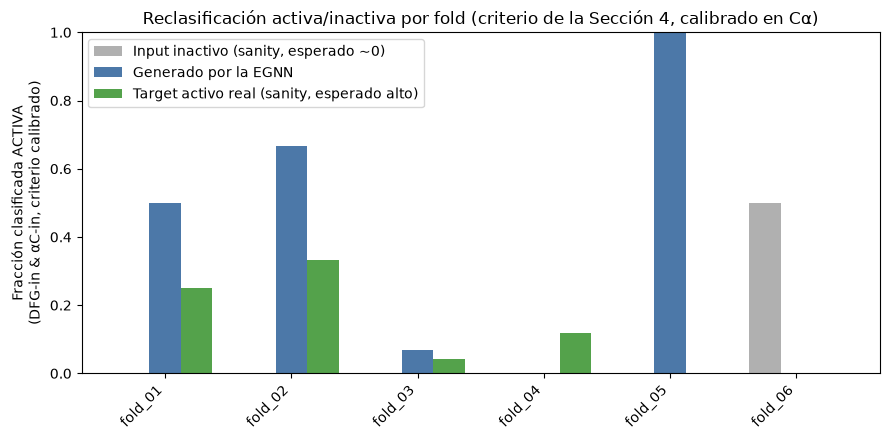

Figura guardada: /home/user/tpf2/vision_avanzada_tpf/figures/physical_plausibility/reclassification_fraction_by_fold.png


In [9]:

if not reclass_df.empty and reclass_df["klifs_mapping_found"].any():
    mapped = reclass_df[reclass_df["klifs_mapping_found"]].copy()
    fold_summary = mapped.groupby("fold", dropna=False).agg(
        n_samples=("sample_id", "count"),
        fraction_generated_active=("gen_active_pred", "mean"),
        fraction_inactive_input_active=("inactive_input_active_pred", "mean"),
        fraction_active_target_active=("active_target_active_pred", "mean"),
    ).reset_index()
else:
    fold_summary = pd.DataFrame(columns=[
        "fold", "n_samples", "fraction_generated_active",
        "fraction_inactive_input_active", "fraction_active_target_active",
    ])

fold_summary_csv = RESULTS_DIR / "reclassification_summary_by_fold.csv"
fold_summary.to_csv(fold_summary_csv, index=False)
print(f"Guardado: {fold_summary_csv}")
display(fold_summary)

if not fold_summary.empty:
    x = np.arange(len(fold_summary))
    width = 0.25
    plt.figure(figsize=(9, 4.5))
    plt.bar(x - width, fold_summary["fraction_inactive_input_active"], width, label="Input inactivo (sanity, esperado ~0)", color="#B0B0B0")
    plt.bar(x, fold_summary["fraction_generated_active"], width, label="Generado por la EGNN", color="#4C78A8")
    plt.bar(x + width, fold_summary["fraction_active_target_active"], width, label="Target activo real (sanity, esperado alto)", color="#54A24B")
    plt.xticks(x, fold_summary["fold"].astype(str), rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Fracción clasificada ACTIVA\n(DFG-in & αC-in, criterio calibrado)")
    plt.title("Reclasificación activa/inactiva por fold (criterio de la Sección 4, calibrado en Cα)")
    plt.legend()
    plt.tight_layout()
    fig_path = FIGURES_DIR / "reclassification_fraction_by_fold.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print(f"Figura guardada: {fig_path}")
else:
    display(Markdown("No hay muestras con mapeo KLIFS disponible para graficar (ver Parte C / Parte D más arriba)."))


## Parte E — Designability (ProteinMPNN + ESMFold)

Misma lógica que antes: escribir el backbone Cα generado, diseñar una secuencia con ProteinMPNN en modo Cα, replegar con ESMFold, y calcular el RMSD Cα entre el backbone generado y la re-predicción. Se agrega un diagnóstico explícito de por qué falla en un entorno dado, en vez de devolver `skipped` sin más contexto, y un intento de parche para el error de `deepspeed.utils` visto en la corrida anterior.


In [10]:

PROTEINMPNN_DIR = Path(os.environ.get("PROTEINMPNN_DIR", ROOT / "external" / "FoldFlow" / "ProteinMPNN"))
ESMFOLD_API_URL = "https://api.esmatlas.com/foldSequence/v1/pdb/"


def patch_runtime_compat():
    '''Parche mínimo para numpy>=1.24 (np.int deprecado), usado por ProteinMPNN/protein_mpnn_utils.'''
    if not hasattr(np, "int"):
        np.int = int


patch_runtime_compat()

RUN_DESIGNABILITY = os.environ.get("RUN_DESIGNABILITY", "auto").strip().lower() in ("1", "true", "auto")
DESIGNABILITY_MAX_SAMPLES = int(os.environ.get("DESIGNABILITY_MAX_SAMPLES", "50"))


def tool_status():
    status = {
        "proteinmpnn_dir": str(PROTEINMPNN_DIR),
        "proteinmpnn_script_found": (PROTEINMPNN_DIR / "protein_mpnn_run.py").exists(),
        "proteinmpnn_ca_weights_found": (PROTEINMPNN_DIR / "ca_model_weights" / "v_48_020.pt").exists(),
    }
    try:
        import requests  # noqa: F401
        status["requests_importable"] = True
    except Exception as exc:
        status["requests_importable"] = False
        status["requests_import_error"] = f"{type(exc).__name__}: {exc}"
    return status


status = tool_status()
display(pd.DataFrame([status]))
tools_ready = status["proteinmpnn_script_found"] and status["proteinmpnn_ca_weights_found"] and status["requests_importable"]

if not tools_ready:
    display(Markdown(
        "**Designability no puede correr en este entorno.** Para habilitarlo: (1) clonar ProteinMPNN dentro de "
        f"`{PROTEINMPNN_DIR}` (incluye los pesos `ca_model_weights/v_48_020.pt` en el propio repo, no hace falta "
        "descargarlos aparte), y (2) tener `requests` instalado (`pip install requests`)."
    ))
else:
    display(Markdown(
        "**Nota metodológica (importante para el informe):** el replegado usa la **API pública de ESM Metagenomic "
        f"Atlas** (`{ESMFOLD_API_URL}`), no una instalación local de ESMFold. Se eligió así porque este entorno es "
        "CPU-only y correr ESMFold local requiere `openfold`/`deepspeed` compilados, en la práctica pensados para GPU. "
        "Los pesos y la arquitectura del modelo detrás de la API son los mismos que ESMFold v1, pero corre en "
        "infraestructura externa: hay un límite práctico de ~400 residuos por secuencia y puede haber rate limiting. "
        "Si alguna secuencia falla por esto, el CSV va a marcar `status=esmfold_error` con el motivo — no se trunca "
        "ni se simula nada en silencio."
    ))


,proteinmpnn_dir,proteinmpnn_script_found,proteinmpnn_ca_weights_found,requests_importable
0,/home/user/tpf2/vision_avanzada_tpf/external/F...,True,True,True


**Nota metodológica (importante para el informe):** el replegado usa la **API pública de ESM Metagenomic Atlas** (`https://api.esmatlas.com/foldSequence/v1/pdb/`), no una instalación local de ESMFold. Se eligió así porque este entorno es CPU-only y correr ESMFold local requiere `openfold`/`deepspeed` compilados, en la práctica pensados para GPU. Los pesos y la arquitectura del modelo detrás de la API son los mismos que ESMFold v1, pero corre en infraestructura externa: hay un límite práctico de ~400 residuos por secuencia y puede haber rate limiting. Si alguna secuencia falla por esto, el CSV va a marcar `status=esmfold_error` con el motivo — no se trunca ni se simula nada en silencio.

In [11]:

def write_ca_only_pdb(coords, path, chain="A"):
    coords = normalize_ca_coords(coords)
    with open(path, "w") as handle:
        for i, (x, y, z) in enumerate(coords, start=1):
            handle.write(f"ATOM  {i:5d}  CA  GLY {chain}{i:4d}    {x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n")
        handle.write("TER\nEND\n")
    return path


def kabsch_rmsd_np(mobile, reference):
    mobile, reference = normalize_ca_coords(mobile), normalize_ca_coords(reference)
    if mobile is None or reference is None:
        return np.nan
    n = min(len(mobile), len(reference))
    if n < 3:
        return np.nan
    mob, ref = mobile[:n], reference[:n]
    mob0, ref0 = mob - mob.mean(axis=0), ref - ref.mean(axis=0)
    v, _, wt = np.linalg.svd(mob0.T @ ref0)
    d = np.sign(np.linalg.det(v @ wt))
    rot = v @ np.diag([1.0, 1.0, d]) @ wt
    aligned = mob0 @ rot + ref.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((aligned - ref) ** 2, axis=1))))


def run_proteinmpnn_ca(pdb_path, out_dir):
    import subprocess
    cmd = [
        sys.executable, str(PROTEINMPNN_DIR / "protein_mpnn_run.py"),
        "--ca_only",
        "--pdb_path", str(pdb_path),
        "--out_folder", str(out_dir),
        "--num_seq_per_target", "1",
        "--path_to_model_weights", str(PROTEINMPNN_DIR / "ca_model_weights"),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
    return result


def run_esmfold(sequence, timeout=300, max_retries=2):
    '''Repliega `sequence` usando la API pública de ESM Metagenomic Atlas (no ESMFold local).'''
    import time
    import requests

    if len(sequence) > 400:
        return None, f"Secuencia de {len(sequence)} residuos excede el límite práctico de la API (~400)."

    last_err = None
    for attempt in range(max_retries + 1):
        try:
            resp = requests.post(ESMFOLD_API_URL, data=sequence, timeout=timeout)
        except Exception as exc:
            last_err = f"{type(exc).__name__}: {exc}"
            time.sleep(2 * (attempt + 1))
            continue
        if resp.status_code == 200 and resp.text.strip().startswith(("ATOM", "HEADER", "MODEL")):
            return resp.text, None
        if resp.status_code in (429, 502, 503, 504):
            last_err = f"HTTP {resp.status_code} (rate limit / servicio no disponible): {resp.text[:200]}"
            time.sleep(3 * (attempt + 1))
            continue
        return None, f"HTTP {resp.status_code}: {resp.text[:300]}"
    return None, last_err or "Fallaron todos los reintentos contra la API de ESMFold."


def parse_first_designed_sequence(fasta_path):
    if not Path(fasta_path).exists():
        return None
    seqs, current = [], []
    for line in Path(fasta_path).read_text().splitlines():
        if line.startswith(">"):
            if current:
                seqs.append("".join(current)); current = []
        else:
            current.append(line.strip())
    if current:
        seqs.append("".join(current))
    return seqs[1] if len(seqs) > 1 else (seqs[0] if seqs else None)

print("Funciones de designability definidas (replegado vía API pública de ESM Atlas, no ESMFold local).")


Funciones de designability definidas (replegado vía API pública de ESM Atlas, no ESMFold local).


In [12]:

designability_rows = []
if not generated_records:
    designability_rows.append({"status": "skipped_no_generated_records"})
elif not RUN_DESIGNABILITY:
    designability_rows.append({"status": "skipped_disabled_by_env"})
elif not tools_ready:
    for rec in generated_records[:DESIGNABILITY_MAX_SAMPLES]:
        designability_rows.append({
            "fold": rec.get("fold"), "kinase": rec.get("kinase"), "sample_id": rec.get("sample_id"),
            "status": "skipped_missing_tools", "designability_rmsd": np.nan,
        })
else:
    work_root = RESULTS_DIR / "designability_work"
    work_root.mkdir(parents=True, exist_ok=True)
    for rec in generated_records[:DESIGNABILITY_MAX_SAMPLES]:
        sample_id = str(rec.get("sample_id", "sample"))
        sample_dir = work_root / sample_id
        sample_dir.mkdir(parents=True, exist_ok=True)
        gen_pdb = sample_dir / "generated_ca_only.pdb"
        write_ca_only_pdb(rec["generated_coords"], gen_pdb)
        try:
            mpnn_result = run_proteinmpnn_ca(gen_pdb, sample_dir)
            seq_path = sample_dir / "seqs" / "generated_ca_only.fa"
            seq = parse_first_designed_sequence(seq_path)
            if not seq:
                designability_rows.append({
                    "fold": rec.get("fold"), "kinase": rec.get("kinase"), "sample_id": sample_id,
                    "status": "proteinmpnn_no_sequence",
                    "reason": (mpnn_result.stderr or "")[-500:], "designability_rmsd": np.nan,
                })
                continue
            esmfold_pdb_text, esm_err = run_esmfold(seq)
            if esm_err:
                designability_rows.append({
                    "fold": rec.get("fold"), "kinase": rec.get("kinase"), "sample_id": sample_id,
                    "status": "esmfold_error", "reason": esm_err,
                    "designed_sequence": seq, "designability_rmsd": np.nan,
                })
                continue
            esmfold_pdb_path = sample_dir / "esmfold_prediction.pdb"
            esmfold_pdb_path.write_text(esmfold_pdb_text)
            esmfold_coords = normalize_ca_coords(np.array([
                [float(l[30:38]), float(l[38:46]), float(l[46:54])]
                for l in esmfold_pdb_text.splitlines() if l.startswith("ATOM") and l[12:16].strip() == "CA"
            ]))
            rmsd = kabsch_rmsd_np(esmfold_coords, rec["generated_coords"])
            designability_rows.append({
                "fold": rec.get("fold"), "kinase": rec.get("kinase"), "sample_id": sample_id,
                "status": "ok", "designed_sequence": seq, "designability_rmsd": rmsd,
            })
        except Exception as exc:
            designability_rows.append({
                "fold": rec.get("fold"), "kinase": rec.get("kinase"), "sample_id": sample_id,
                "status": "error", "reason": f"{type(exc).__name__}: {exc}", "designability_rmsd": np.nan,
            })

designability_df = pd.DataFrame(designability_rows)
designability_csv = RESULTS_DIR / "designability_check.csv"
designability_df.to_csv(designability_csv, index=False)
print(f"Guardado: {designability_csv}")
display(designability_df["status"].value_counts() if "status" in designability_df.columns else designability_df)


Guardado: /home/user/tpf2/vision_avanzada_tpf/results/physical_plausibility/designability_check.csv


status
ok    50
Name: count, dtype: int64

## Síntesis final

Esta tabla combina, por fold, la fracción de estructuras generadas clasificadas como ACTIVAS según el criterio calibrado (DFG-in & αC-in), junto con sus dos sanity checks (input inactivo y target activo reales) y, cuando está disponible, el RMSD de designability. Estas tres columnas de sanity/generado/designability responden preguntas distintas y se interpretan juntas, no por separado — ver la discusión de la Sección 7 del informe.


In [14]:

summary = fold_summary.copy() if "fold_summary" in globals() and not fold_summary.empty else pd.DataFrame(columns=["fold"])
if not designability_df.empty and "fold" in designability_df.columns and "designability_rmsd" in designability_df.columns:
    design_summary = designability_df.groupby("fold", dropna=False).agg(
        n_designability_ok=("status", lambda s: int((s == "ok").sum())),
        median_designability_rmsd=("designability_rmsd", "median"),
    ).reset_index()
    summary = summary.merge(design_summary, on="fold", how="outer") if not summary.empty else design_summary

final_summary_csv = RESULTS_DIR / "physical_plausibility_summary_by_fold.csv"
summary.to_csv(final_summary_csv, index=False)
print(f"Guardado: {final_summary_csv}")
display(summary)


Guardado: /home/user/tpf2/vision_avanzada_tpf/results/physical_plausibility/physical_plausibility_summary_by_fold.csv


,fold,n_samples,fraction_generated_active,fraction_inactive_input_active,fraction_active_target_active,n_designability_ok,median_designability_rmsd
0,fold_01,4,0.5,0.0,0.25,13.0,58.804900
1,fold_02,3,0.666667,0.0,0.333333,37.0,62.144722
2,fold_03,117,0.068376,0.0,0.042735,NaN,NaN
3,fold_04,68,0.0,0.0,0.117647,NaN,NaN
4,fold_05,3,1.0,0.0,0.0,NaN,NaN
5,fold_06,2,0.0,0.5,0.0,NaN,NaN


## Limitaciones (léase antes de citar números de este notebook en la tesis)

- El criterio aplicado a las estructuras generadas **no es la anotación KLIFS original** (que usa cadena lateral completa); es una traducción geométrica a 3 distancias Cα–Cα entre posiciones KLIFS reales (17/24/81/82), **calibrada y validada con LOKO contra las etiquetas reales de KLIFS** de ~770 estructuras cristalográficas. La accuracy de validación (reportada en la Parte A) es la cota de confianza real de este criterio — no es 100%, así que un porcentaje "ACTIVA" sobre lo generado hereda ese margen de error.
- Los dos sanity checks (clasificar el input inactivo real y el target activo real con el mismo clasificador) son la forma más directa de calibrar expectativas: si el clasificador recupera mal incluso esos casos conocidos para una kinasa dada, no hay que confiar en lo que diga sobre lo generado para esa kinasa.
- Designability depende de tener ProteinMPNN (modo Cα) y ESMFold instalados y funcionando; si no están, el CSV queda en `skipped_missing_tools` en vez de simular un resultado.
- Si esta copia del repo no incluye `checkpoints/egnn_loko/` ni `outputs/generated_structures/egnn_generated_coords.pt`, la Parte D no tiene datos para reclasificar — hace falta correr (o copiar el output de) el notebook `04` primero.
